# Time-Table Optimizer — Step 3 Baseline Scheduler

This is the project-specific baseline stage. It uses the clean Step 2 scenario file and a deterministic first-fit room/slot placement rule. It is **not** an ANN and it does not claim to train a model. Run `python src/run_baseline.py` from the repository root to regenerate the full schedule and metrics.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'src' / 'run_baseline.py').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.run_baseline import DATA_FILE, RESULTS_DIR, load_scenarios, schedule_one_scenario, audit_schedule

print('Project root:', PROJECT_ROOT)
print('Step 2 input:', DATA_FILE.relative_to(PROJECT_ROOT))
assert DATA_FILE.exists(), 'Run python src/prepare_data.py first.'

Project root: c:\Users\shour\Desktop\Time-Table Optimizer\Time-Table-Optimizer
Step 2 input: data\processed\cleaned_scenarios.csv


In [2]:
input_df = load_scenarios()
scenario_types = input_df[['scenario_id', 'case_type']].drop_duplicates()['case_type'].value_counts()
print('BASELINE INPUT CHECK')
print('Course records:', f'{len(input_df):,}')
print('Scenarios:', f'{input_df.scenario_id.nunique():,}')
print('Missing values:', int(input_df.isna().sum().sum()))
print('Duplicate rows:', int(input_df.duplicated().sum()))
print('Scenario categories:')
print(scenario_types)
display(input_df.head())

BASELINE INPUT CHECK
Course records: 50,000
Scenarios: 10,000
Missing values: 0
Duplicate rows: 0
Scenario categories:
case_type
normal      7000
boundary    2000
stress      1000
Name: count, dtype: int64


,scenario_id,case_type,course_id,cohort_id,faculty_id,weekly_sessions,duration_slots,required_room_type,room_capacity,room_type,slot_id
0,TTO-00001,normal,C01,G1,F1,3,2,classroom,60,classroom,S4
1,TTO-00001,normal,C02,G1,F3,3,1,lab,30,lab,S1
2,TTO-00001,normal,C03,G1,F1,3,1,classroom,60,classroom,S9
3,TTO-00001,normal,C04,G1,F3,3,2,classroom,60,classroom,S8
4,TTO-00001,normal,C05,G2,F1,3,2,lab,30,lab,S5


## Run the baseline on one example scenario

The full 10,000-scenario run is performed by `src/run_baseline.py` in the terminal. This cell runs the algorithm on one representative scenario for easy inspection.

In [3]:
example_id = sorted(input_df['scenario_id'].unique())[0]
example_df = input_df[input_df['scenario_id'] == example_id]
example_records, example_summary = schedule_one_scenario(example_df)
example_schedule = pd.DataFrame(example_records)
print('EXAMPLE SCENARIO:', example_id)
print('Requested sessions:', example_summary['requested_sessions'])
print('Scheduled sessions:', example_summary['scheduled_sessions'])
print('Unplaced sessions:', example_summary['unplaced_sessions'])
print('Preference penalties:', example_summary['preference_penalties'])
display(example_schedule)
assert audit_schedule(example_schedule) == 0, 'Example schedule contains a hard clash.'
print('Example hard clash audit: PASS')

EXAMPLE SCENARIO: TTO-00001
Requested sessions: 15
Scheduled sessions: 7
Unplaced sessions: 8
Preference penalties: 7


,scenario_id,case_type,course_id,session_number,faculty_id,cohort_id,required_room_type,duration_slots,preferred_slot,room_id,room_type,start_slot,occupied_slots,preference_penalty,status,unplaced_reason
0,TTO-00001,normal,C01,1,F1,G1,classroom,2,S4,R1,classroom,S1,S1|S2,1,scheduled,
1,TTO-00001,normal,C01,2,F1,G1,classroom,2,S4,R1,classroom,S3,S3|S4,1,scheduled,
2,TTO-00001,normal,C01,3,F1,G1,classroom,2,S4,R1,classroom,S5,S5|S6,1,scheduled,
3,TTO-00001,normal,C02,1,F3,G1,lab,1,S1,R3,lab,S7,S7,1,scheduled,
4,TTO-00001,normal,C02,2,F3,G1,lab,1,S1,R3,lab,S8,S8,1,scheduled,
5,TTO-00001,normal,C02,3,F3,G1,lab,1,S1,R3,lab,S9,S9,1,scheduled,
6,TTO-00001,normal,C03,1,F1,G1,classroom,1,S9,R1,classroom,S10,S10,1,scheduled,
7,TTO-00001,normal,C03,2,F1,G1,classroom,1,S9,,,,,0,unplaced,No compatible room/slot available without a ha...
8,TTO-00001,normal,C03,3,F1,G1,classroom,1,S9,,,,,0,unplaced,No compatible room/slot available without a ha...
9,TTO-00001,normal,C04,1,F3,G1,classroom,2,S8,,,,,0,unplaced,No compatible room/slot available without a ha...


Example hard clash audit: PASS


## Results from the complete 10,000-scenario run

These CSV files are written when `python src/run_baseline.py` finishes. This notebook reads them to show the aggregate results and evidence.

In [4]:
metrics_path = RESULTS_DIR / 'baseline_metrics.csv'
by_case_path = RESULTS_DIR / 'baseline_metrics_by_case.csv'
schedule_path = RESULTS_DIR / 'baseline_schedule.csv'

if not (metrics_path.exists() and by_case_path.exists() and schedule_path.exists()):
    raise FileNotFoundError('Run python src/run_baseline.py from the repository root first.')

metrics_df = pd.read_csv(metrics_path)
by_case_df = pd.read_csv(by_case_path)
full_schedule_df = pd.read_csv(schedule_path)
print('Scenarios evaluated:', f'{metrics_df.scenario_id.nunique():,}')
print('Course records in scenarios:', f'{int(metrics_df.course_count.sum()):,}')
print('Sessions requested:', f'{int(metrics_df.requested_sessions.sum()):,}')
print('Sessions scheduled:', f'{int(metrics_df.scheduled_sessions.sum()):,}')
print('Sessions unplaced:', f'{int(metrics_df.unplaced_sessions.sum()):,}')
print('Hard violations in saved schedules:', int(metrics_df.hard_violations.sum()))
print('Preference penalties:', f'{int(metrics_df.preference_penalties.sum()):,}')
print()
print('RESULTS BY SCENARIO CATEGORY')
display(by_case_df)
print()
print('SCENARIO METRICS — FIRST FIVE ROWS')
display(metrics_df.head())
assert int(metrics_df.hard_violations.sum()) == 0, 'Saved baseline summary reports hard violations.'

Scenarios evaluated: 10,000
Course records in scenarios: 50,000
Sessions requested: 125,109
Sessions scheduled: 84,845
Sessions unplaced: 40,264
Hard violations in saved schedules: 0
Preference penalties: 76,364

RESULTS BY SCENARIO CATEGORY


,case_type,scenarios,requested_sessions,scheduled_sessions,unplaced_sessions,feasible_scenarios,mean_unplaced_sessions,mean_coverage_pct,mean_room_slot_utilization_pct,preference_penalties,hard_violations,feasibility_rate_pct
0,normal,7000,70118,58451,11667,2583,1.67,84.78,41.00,52640,0,36.9
1,boundary,2000,34991,20494,14497,10,7.25,58.76,49.30,18462,0,0.5
2,stress,1000,20000,5900,14100,0,14.10,29.50,39.33,5262,0,0.0



SCENARIO METRICS — FIRST FIVE ROWS


,scenario_id,case_type,course_count,requested_sessions,scheduled_sessions,unplaced_sessions,unplaced_courses,requested_slot_units,scheduled_slot_units,room_slot_utilization_pct,preference_penalties,feasible,coverage_pct,hard_violations
0,TTO-00001,normal,5,15,7,8,3,24,10,33.33,7,False,46.67,0
1,TTO-00002,normal,5,15,7,8,3,24,10,33.33,6,False,46.67,0
2,TTO-00003,normal,5,15,12,3,1,24,18,60.00,9,False,80.00,0
3,TTO-00004,normal,5,15,7,8,3,21,10,33.33,6,False,46.67,0
4,TTO-00005,normal,5,15,13,2,1,15,13,43.33,12,False,86.67,0


FEASIBILITY RATE BY SCENARIO TYPE


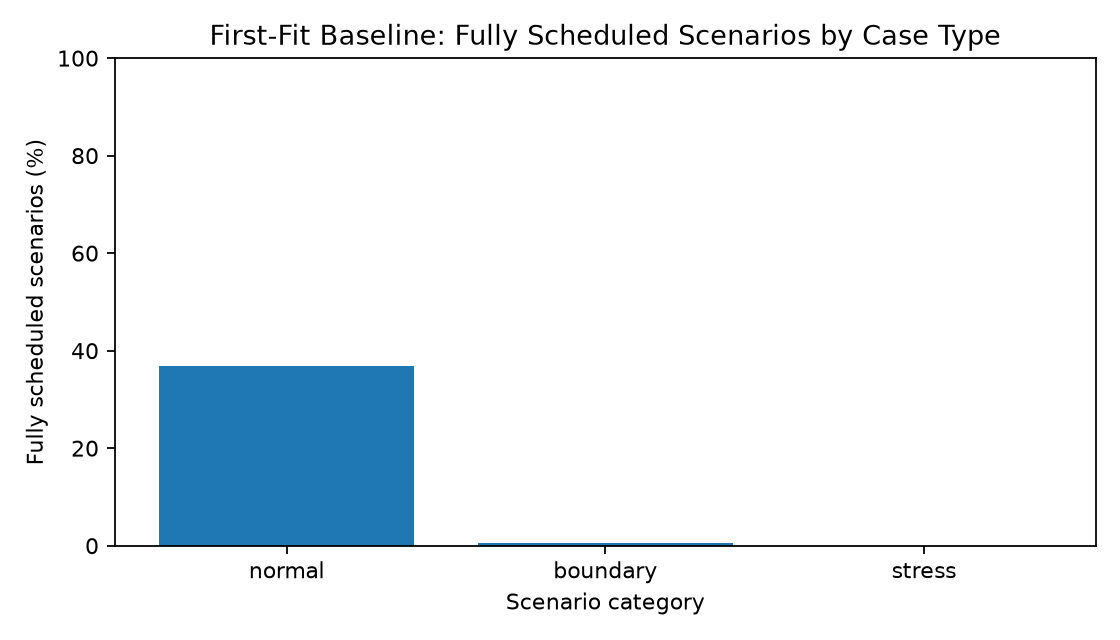

MEAN UNPLACED SESSIONS BY SCENARIO TYPE


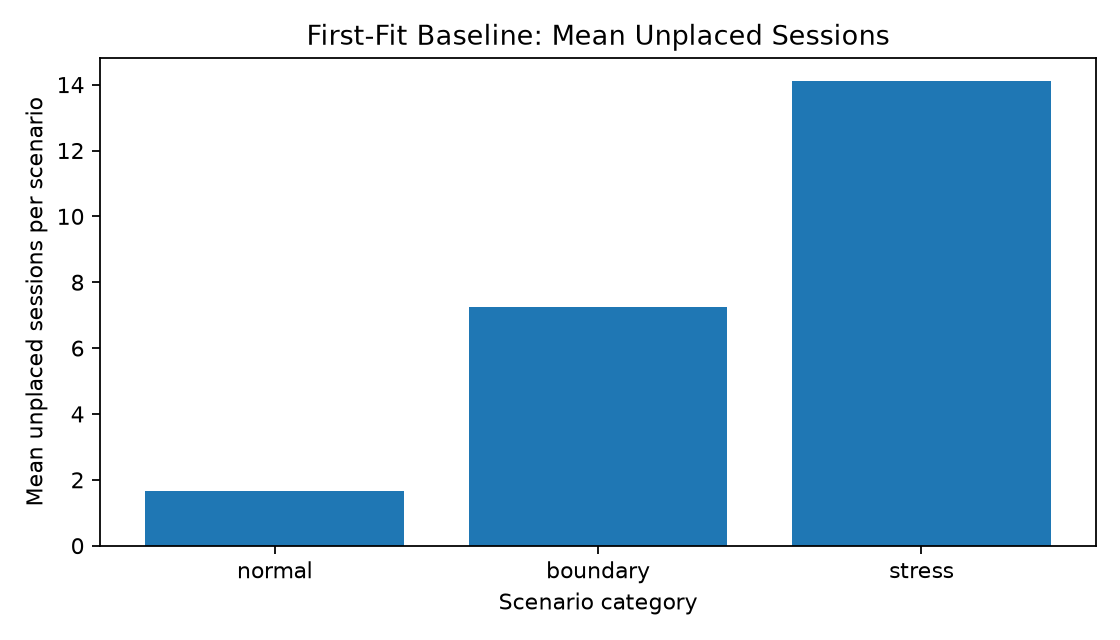

In [5]:
print('FEASIBILITY RATE BY SCENARIO TYPE')
display(Image(filename=str(RESULTS_DIR / 'scenario_feasibility_by_case.png')))
print('MEAN UNPLACED SESSIONS BY SCENARIO TYPE')
display(Image(filename=str(RESULTS_DIR / 'mean_unplaced_sessions_by_case.png')))

## How to interpret the results

- **Scheduled sessions:** meetings assigned to a compatible room and valid time slots.
- **Unplaced sessions:** meetings that could not fit without breaking a hard constraint.
- **Hard violations:** room, faculty, or cohort overlaps; the saved schedule must have zero.
- **Preference penalties:** a scheduled session starts outside that course's `slot_id` preference. This is a soft penalty, not a hard failure.
- **Feasibility rate:** percentage of scenarios where every requested session was assigned.

The baseline is intentionally simple. The later Genetic Algorithm should be compared using the same scenario inputs and hard constraints. All scenarios are simulated educational data, not real university timetable records.